# Students Database

In [5]:
from mermaid import Mermaid

## Conceptual Data Model

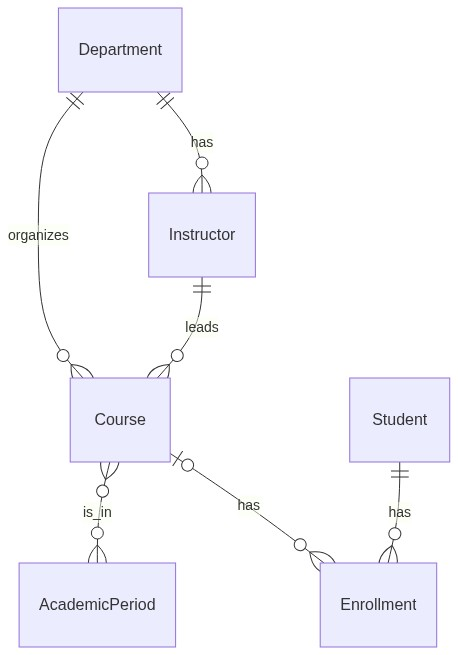

In [30]:
%%mermaidjs --img
erDiagram


    Course }o--o{ AcademicPeriod : is_in
    Student ||--o{ Enrollment : has
    Course |o--o{ Enrollment : has
    Department ||--o{ Course : organizes
    Department ||--o{ Instructor : has
    Instructor ||--o{ Course : leads


* in conceptual datamodel
  * attributes are not required
  * relationship type is not required
* in logical datamodel:
  * full list of attributes
  * define PK and FK
  * define relationships with their type (cardinality)
  * independent of the DBMS - generic

## Logical Data Model

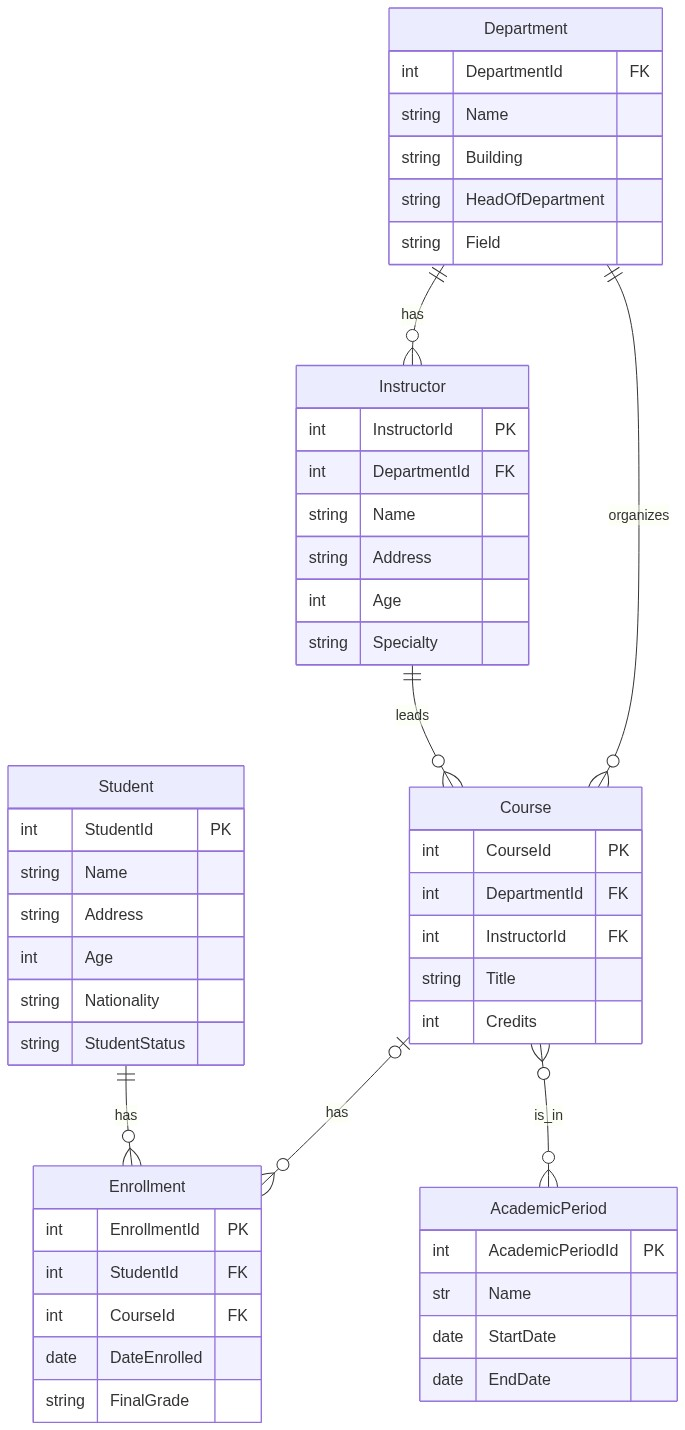

In [26]:
%%mermaidjs --img
erDiagram

    Student {
        int StudentId PK
        string Name
        string Address
        int Age
        string Nationality
        string StudentStatus
    }

    Enrollment {
        int EnrollmentId PK
        int StudentId FK
        int CourseId FK
        date DateEnrolled
        string FinalGrade
    }

    Course {
        int CourseId PK
        int DepartmentId FK
        int InstructorId FK
        string Title
        int Credits
    }

    AcademicPeriod {
        int AcademicPeriodId PK
        str Name
        date StartDate
        date EndDate
    }

    Instructor {
        int InstructorId PK
        int DepartmentId FK
        string Name
        string Address
        int Age
        string Specialty
    }

    Department {
        int DepartmentId FK
        string Name
        string Building
        string HeadOfDepartment
        string Field
    }

    Course }o--o{ AcademicPeriod : is_in
    Student ||--o{ Enrollment : has
    Course |o--o{ Enrollment : has
    Department ||--o{ Course : organizes
    Department ||--o{ Instructor : has
    Instructor ||--o{ Course : leads


### Data Types in Logical Data Model

* Data types are not required in logical data model
* You could use generic data types - date, string, integer as they are not connected to any RDBMS, but provide some info on the nature of the attribute.


## Physical Data Model

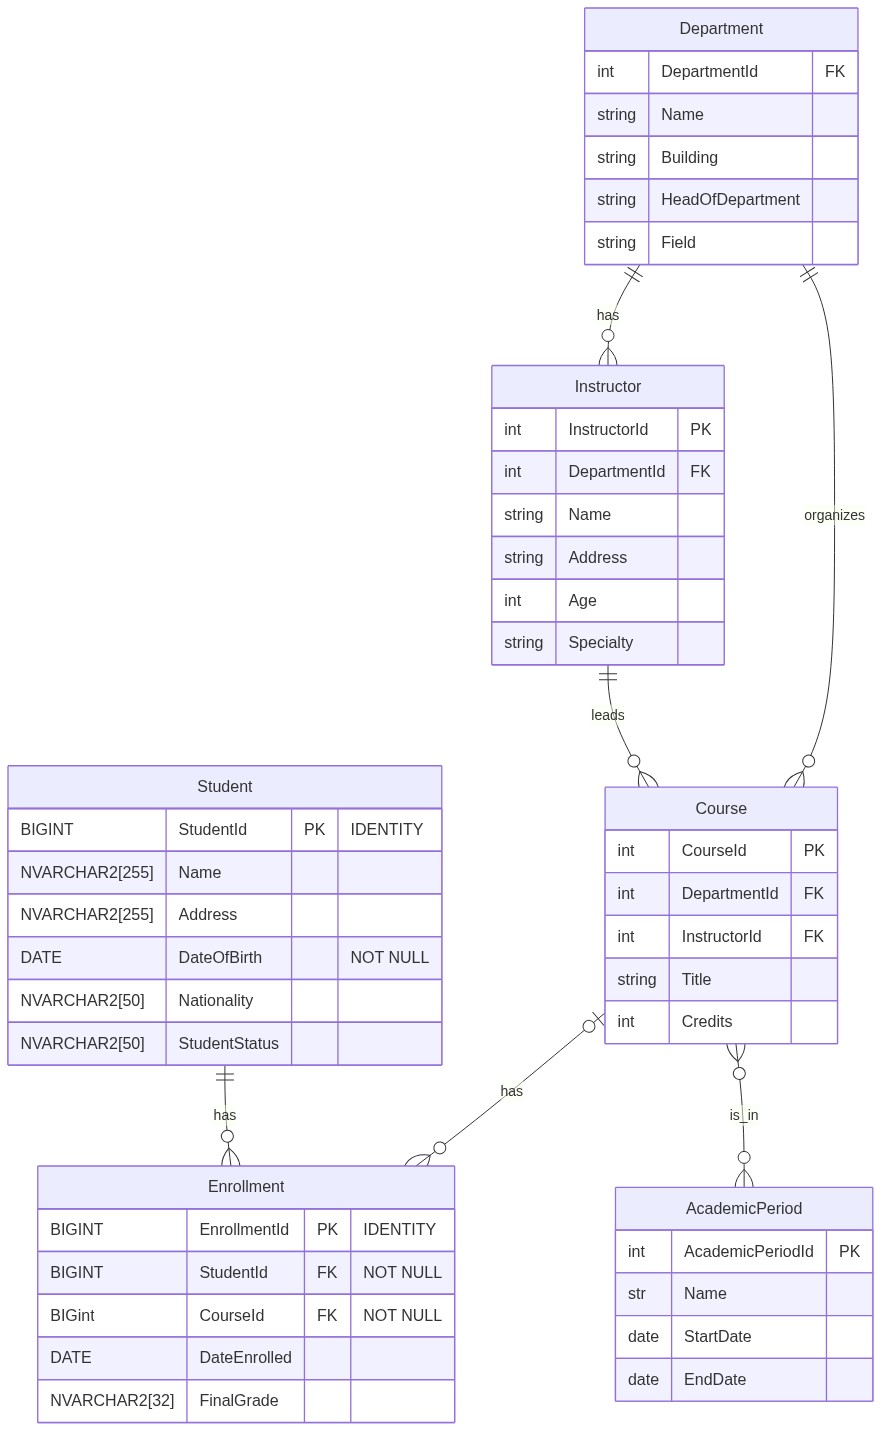

In [34]:
%%mermaidjs --img
erDiagram

    Student {
        BIGINT StudentId PK "IDENTITY"
        NVARCHAR2[255] Name
        NVARCHAR2[255] Address
        DATE DateOfBirth "NOT NULL"
        NVARCHAR2[50] Nationality
        NVARCHAR2[50] StudentStatus
    }

    Enrollment {
        BIGINT EnrollmentId PK "IDENTITY"
        BIGINT StudentId FK "NOT NULL"
        BIGint CourseId FK "NOT NULL"
        DATE DateEnrolled
        NVARCHAR2[32] FinalGrade
    }

    Course {
        int CourseId PK
        int DepartmentId FK
        int InstructorId FK
        string Title
        int Credits
    }

    AcademicPeriod {
        int AcademicPeriodId PK
        str Name
        date StartDate
        date EndDate
    }

    Instructor {
        int InstructorId PK
        int DepartmentId FK
        string Name
        string Address
        int Age
        string Specialty
    }

    Department {
        int DepartmentId FK
        string Name
        string Building
        string HeadOfDepartment
        string Field
    }

    Course }o--o{ AcademicPeriod : is_in
    Student ||--o{ Enrollment : has
    Course |o--o{ Enrollment : has
    Department ||--o{ Course : organizes
    Department ||--o{ Instructor : has
    Instructor ||--o{ Course : leads


In Physical Data Model:
* Add data types, specific to the RDBMS
* Add constraints, e.g. NULL/NOT NULL, IDENTITY/AUTO_INCREMENT
* Add delete behavior on FK, e.g. ON DELETE SET NULL or ON DELETE CASCADE
* Additional infromation could be specified as partitioning, database engine, etc.

In [36]:
! uv pip install lark-dbml[sql]

Using Python 3.14.7 environment at: C:\Users\ivang\Desktop\sandbox\sandbox\.venv
Resolved 7 packages in 573ms
Prepared 1 package in 571ms
Installed 1 package in 78ms
 + sqlglot==30.18.0


In [38]:
from lark_dbml import load, loads

# 1. Read from a string
dbml = """
Project "My Database" {
  database_type: 'PostgreSQL'
  Note: "This is a sample database"
}

Table "users" {
  id int [pk, increment]
  username varchar [unique, not null]
  email varchar [unique]
  created_at timestamp [default: `now()`]
}

Table "posts" {
  id int [pk, increment]
  title varchar
  content text
  user_id int
}

Ref: posts.user_id > users.id
"""

# Default option
diagram = loads(dbml)
# Change to Lark mode
diagram = loads(dbml, standalone_mode=False)
# Switch to Earley algorithm
diagram = loads(dbml, parser="earley")

# 2. Read from a file
# diagram = load('example.dbml')

In [42]:
from lark_dbml import dump, dumps

from lark_dbml.converter.dbml import DBMLConverterSettings

# This includes partitioned_by in the output
dbml = dumps(diagram,
      settings=DBMLConverterSettings(
          allow_extra=True
      )
)

print(dbml)
# Write the DBML to file
# dump(diagram, 'diagram.dbml')

Project "My Database" {
    database_type: 'PostgreSQL'
    note: 'This is a sample database'
}

Table users {
    id int [pk, increment]
    username varchar [not null, unique]
    email varchar [unique]
    created_at timestamp [default: `now()`]
}

Table posts {
    id int [pk, increment]
    title varchar
    content text
    user_id int
}

Ref: posts.user_id > users.id




In [45]:
from lark_dbml import load
from lark_dbml.converter import to_sql
from sqlglot import Dialects

# Load DBML diagram
# diagram = load("diagram.dbml")

# Convert to SQL for PostgreSQL
sql = to_sql(diagram, Dialects.DATABRICKS)

In [44]:
print(sql)

CREATE TABLE "users" (
  "id" INT GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
  "username" VARCHAR UNIQUE NOT NULL,
  "email" VARCHAR UNIQUE,
  "created_at" TIMESTAMP DEFAULT now()
);

CREATE TABLE "posts" (
  "id" INT GENERATED ALWAYS AS IDENTITY PRIMARY KEY,
  "title" VARCHAR,
  "content" TEXT,
  "user_id" INT,
  CONSTRAINT  FOREIGN KEY ("user_id") REFERENCES "users" (
    "id"
  )
);




In [49]:
from lark_dbml.converter import to_mermaid

mermaid = to_mermaid(diagram)
print(mermaid)

ValidationError: 3 validation errors for Reference
relationship
  Field required [type=missing, input_value={'to_columns': None}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
to_table
  Field required [type=missing, input_value={'to_columns': None}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
to_columns
  Input should be a valid list [type=list_type, input_value=None, input_type=NoneType]
    For further information visit https://errors.pydantic.dev/2.13/v/list_type

## Resources
* https://sqltoerdiagram.com/
* https://erddocs.com/dbml-to-mermaid/
* https://github.com/MohammadRaziei/mermaidx